# Pemodelan Prediksi Suhu Permukaan Jawa
## Regresi Multivariat + EXDM Optimizer | Data CORDEX-CMIP5

---

**Dataset**: CORDEX South-East Asia (SEA) — Domain 0.22° × 0.22°  
**Sumber**: Climate Data Store (CDS) Copernicus — https://cds.climate.copernicus.eu/  
**GCM Driver**: MOHC-HadGEM2-ES (CMIP5)  
**RCM**: SMHI-RCA4  
**Skenario**: Historical (1976–2005), RCP4.5, RCP8.5 (2006–2100)  
**Area**: Pulau Jawa — BBox lat[-8.8, -5.9] lon[105.1, 115.7]  

---

### Referensi Utama
- Tangang et al. (2020) — CORDEX-SEA: *An integrated regional climate model projection for Southeast Asia* — Climate Dynamics
- Beucler et al. (2021) — *Climate-Invariant Machine Learning* — arXiv:2112.08440
- Li et al. (2010) — EDCDF Bias Correction — J. Hydrology
- Ghaemi et al. (2023) — Regional Temperature Projection arXiv:2504.19145

---

In [51]:

# SETUP — Import libraries 

import sys, os
sys.path.insert(0, '../direktori_tools_cleaning_data')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Tools proyek
class MultivariateRegressionModel:
    def __init__(self, l2_lambda=1e-4):
        self.l2_lambda = l2_lambda
        self.weights = None
        self.bias = None

    def fit(self, X_train, y_train, *args, **kwargs):
        import numpy as np
        X_design = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
        I = np.eye(X_design.shape[1])
        I[0, 0] = 0 
        theta = np.linalg.pinv(X_design.T @ X_design + self.l2_lambda * I) @ X_design.T @ y_train
        self.bias = theta[0]
        self.weights = theta[1:]
        import pandas as pd
        # Create dummy importance based on normalized weights
        abs_weights = np.abs(self.weights)
        importance = abs_weights / (np.sum(abs_weights) + 1e-8)
        self.feature_importance_df = pd.DataFrame({"weight": self.weights, "importance": importance})
        return self

    def predict(self, X):
        return X @ self.weights + self.bias
        
    def evaluate(self, X, y):
        import numpy as np
        y_pred = self.predict(X)
        residuals = y - y_pred
        mse = np.mean(residuals**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(residuals))
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        return {"MSE": float(mse), "RMSE": float(rmse), "MAE": float(mae), "R2": float(r2)}
        
    def get_feature_importance(self, feature_names):
        self.feature_importance_df['feature'] = feature_names
        return self.feature_importance_df.sort_values("importance", ascending=False)
        
        
    def save(self, model_dir):
        import os, numpy as np
        os.makedirs(model_dir, exist_ok=True)
        np.save(os.path.join(model_dir, 'weights.npy'), self.weights)
        np.save(os.path.join(model_dir, 'bias.npy'), np.array([self.bias]))
        
class ZScoreNormalizer:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        import numpy as np
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

        
    def save(self, filepath):
        import numpy as np
        np.savez(filepath, mean=self.mean, std=self.std_)

from bias_corrector import EDCDFBiasCorrector

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup selesai ✓')
# Konfigurasi global Matplotlib agar ukuran font seragam dan mudah diubah
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})


Setup selesai ✓


---
## 1. Eksplorasi Data (EDA)

In [52]:
# ── Load data ───────────────────────────────────────────────────
DATA_PATH   = '../data/processed/features/X_historical.csv'
TARGET_PATH = '../data/processed/targets/y_historical.csv'
RAW_PATH    = '../tmp_folder/historical_raw.csv'

df_raw = pd.read_csv(RAW_PATH, parse_dates=["time"])
df_X   = pd.read_csv(DATA_PATH, parse_dates=['time'])
df_y   = pd.read_csv(TARGET_PATH, parse_dates=['time'])

print(f'Data mentah : {df_raw.shape}')
print(f'Data fitur  : X={df_X.shape}')
print(f'Data target : y={df_y.shape}')

# if os.path.exists(DATA_PATH):
#     df_X = pd.read_csv(DATA_PATH, parse_dates=['time'])
#     df_y = pd.read_csv(TARGET_PATH, parse_dates=['time'])
#     print(f'Data dimuat: X={df_X.shape} | y={df_y.shape}')
# else:
#     # Generate data dummy untuk demonstrasi
#     print('[DEMO] Menggunakan data sintetik (CORDEX belum diunduh)...')
#     n = 360  # 30 tahun × 12 bulan
#     dates = pd.date_range('1976-01-01', periods=n, freq='MS')
#     t = np.arange(n)
#     seasonal = np.sin(2 * np.pi * t / 12)
#     trend    = 0.003 * t  # pemanasan ~0.3°C/dekade

#     df_raw = pd.DataFrame({
#         'time':      dates,
#         'temp_2m':   27.0 + 1.5 * seasonal + trend + np.random.normal(0, 0.25, n),
#         'precip':    8.5  + 4.0 * seasonal + np.random.normal(0, 1.0, n),
#         'pressure':  1010 + 2.0 * seasonal + np.random.normal(0, 0.5, n),
#         'humidity':  80.0 + 5.0 * seasonal + np.random.normal(0, 2.0, n),
#         'wind_u':    1.5  + 0.5 * seasonal + np.random.normal(0, 0.2, n),
#         'wind_v':    0.8  + 0.3 * seasonal + np.random.normal(0, 0.2, n),
#         'solar_rad': 200  + 50  * seasonal + np.random.normal(0, 10,  n),
#     })
#     print(f'Data sintetik: {df_raw.shape}')
#     df_raw.head()

Data mentah : (228, 16)
Data fitur  : X=(216, 108)
Data target : y=(216, 2)


In [53]:
# ── Statistik deskriptif ──────────────────────────────────────────
df_X.describe().round(3)

,time,cloud_cover,evaporation,humidity,specific_humidity,precip,pressure,sea_level_pressure,thermal_rad,solar_rad,...,humidity_roll12,pressure_roll3,pressure_roll6,pressure_roll12,solar_rad_roll3,solar_rad_roll6,solar_rad_roll12,month_sin,month_cos,temp_2m_anomaly
count,216,216.000,216.000,216.000,216.000,216.000,216.000,216.000,216.000,216.000,...,216.000,216.000,216.000,216.000,216.000,216.000,216.000,216.000,216.000,216.000
mean,1996-12-15 17:33:20,69.643,4.908,81.337,17.675,6.704,1005.893,1010.026,411.993,220.585,...,81.318,1005.900,1005.907,1005.917,220.529,220.764,220.916,-0.000,-0.000,0.004
min,1988-01-01 00:00:00,52.964,2.728,75.502,16.011,0.654,1002.384,1006.675,387.195,134.194,...,79.548,1003.290,1004.020,1005.101,143.139,162.341,186.354,-1.000,-1.000,-0.481
25%,1992-06-23 12:00:00,66.818,3.872,80.032,17.155,3.885,1005.118,1009.263,405.957,188.681,...,80.896,1005.166,1005.366,1005.642,193.437,202.828,215.670,-0.592,-0.592,-0.154
50%,1996-12-16 12:00:00,70.225,4.789,81.489,17.724,6.518,1005.943,1010.115,412.625,223.803,...,81.265,1005.928,1005.932,1005.963,224.322,221.390,222.827,-0.000,-0.000,0.022
75%,2001-06-08 12:00:00,72.887,5.971,83.035,18.216,9.135,1006.728,1010.860,418.469,253.330,...,81.790,1006.681,1006.462,1006.128,246.697,240.081,227.814,0.592,0.592,0.152
max,2005-12-01 00:00:00,78.336,7.619,85.912,18.892,15.001,1008.973,1012.824,431.001,308.766,...,82.976,1008.152,1007.494,1006.758,299.031,276.385,238.501,1.000,1.000,0.600
std,NaN,4.599,1.180,2.187,0.655,3.670,1.266,1.210,9.004,39.975,...,0.628,1.045,0.743,0.359,33.348,23.899,10.089,0.709,0.709,0.223


In [54]:
df_y.describe().round(3)


,time,temp_2m
count,216,216.000
mean,1996-12-15 17:33:20,26.202
min,1988-01-01 00:00:00,25.446
25%,1992-06-23 12:00:00,25.992
50%,1996-12-16 12:00:00,26.204
75%,2001-06-08 12:00:00,26.439
max,2005-12-01 00:00:00,26.980
std,NaN,0.307


In [55]:
df_raw.head()

,time,cloud_cover,evaporation,humidity,specific_humidity,precip,pressure,sea_level_pressure,thermal_rad,solar_rad,wind_speed,temp_2m,temp_max_24h,temp_min_24h,wind_u,wind_v
0,1986-01-01,68.482090,3.866583,82.443740,18.042032,6.950465,1004.65607,1008.81140,414.17440,239.85652,4.376164,26.277110,27.080507,25.545040,1.016929,0.621993
1,1986-02-01,65.876180,4.456754,81.015510,18.048262,9.800668,1004.66284,1008.83264,414.03850,232.57999,4.707513,26.572737,27.372261,25.881819,2.984695,-0.070768
2,1986-03-01,71.194070,4.155945,84.121574,18.463080,12.477589,1005.36520,1009.49980,422.79770,195.39836,4.793755,26.329529,27.096575,25.700370,3.298312,-0.462000
3,1986-04-01,64.520480,3.750965,81.886696,18.014803,6.989603,1005.64800,1009.82324,412.15048,225.05072,4.194343,26.377607,27.162231,25.645910,1.086037,0.701887
4,1986-05-01,70.366554,5.005350,83.174340,17.983364,9.771659,1005.64340,1009.83704,416.82040,174.50864,5.535511,26.099764,26.872175,25.428951,-3.632654,2.570219


FileNotFoundError: [Errno 2] No such file or directory: '../results/figures/eda_timeseries.png'

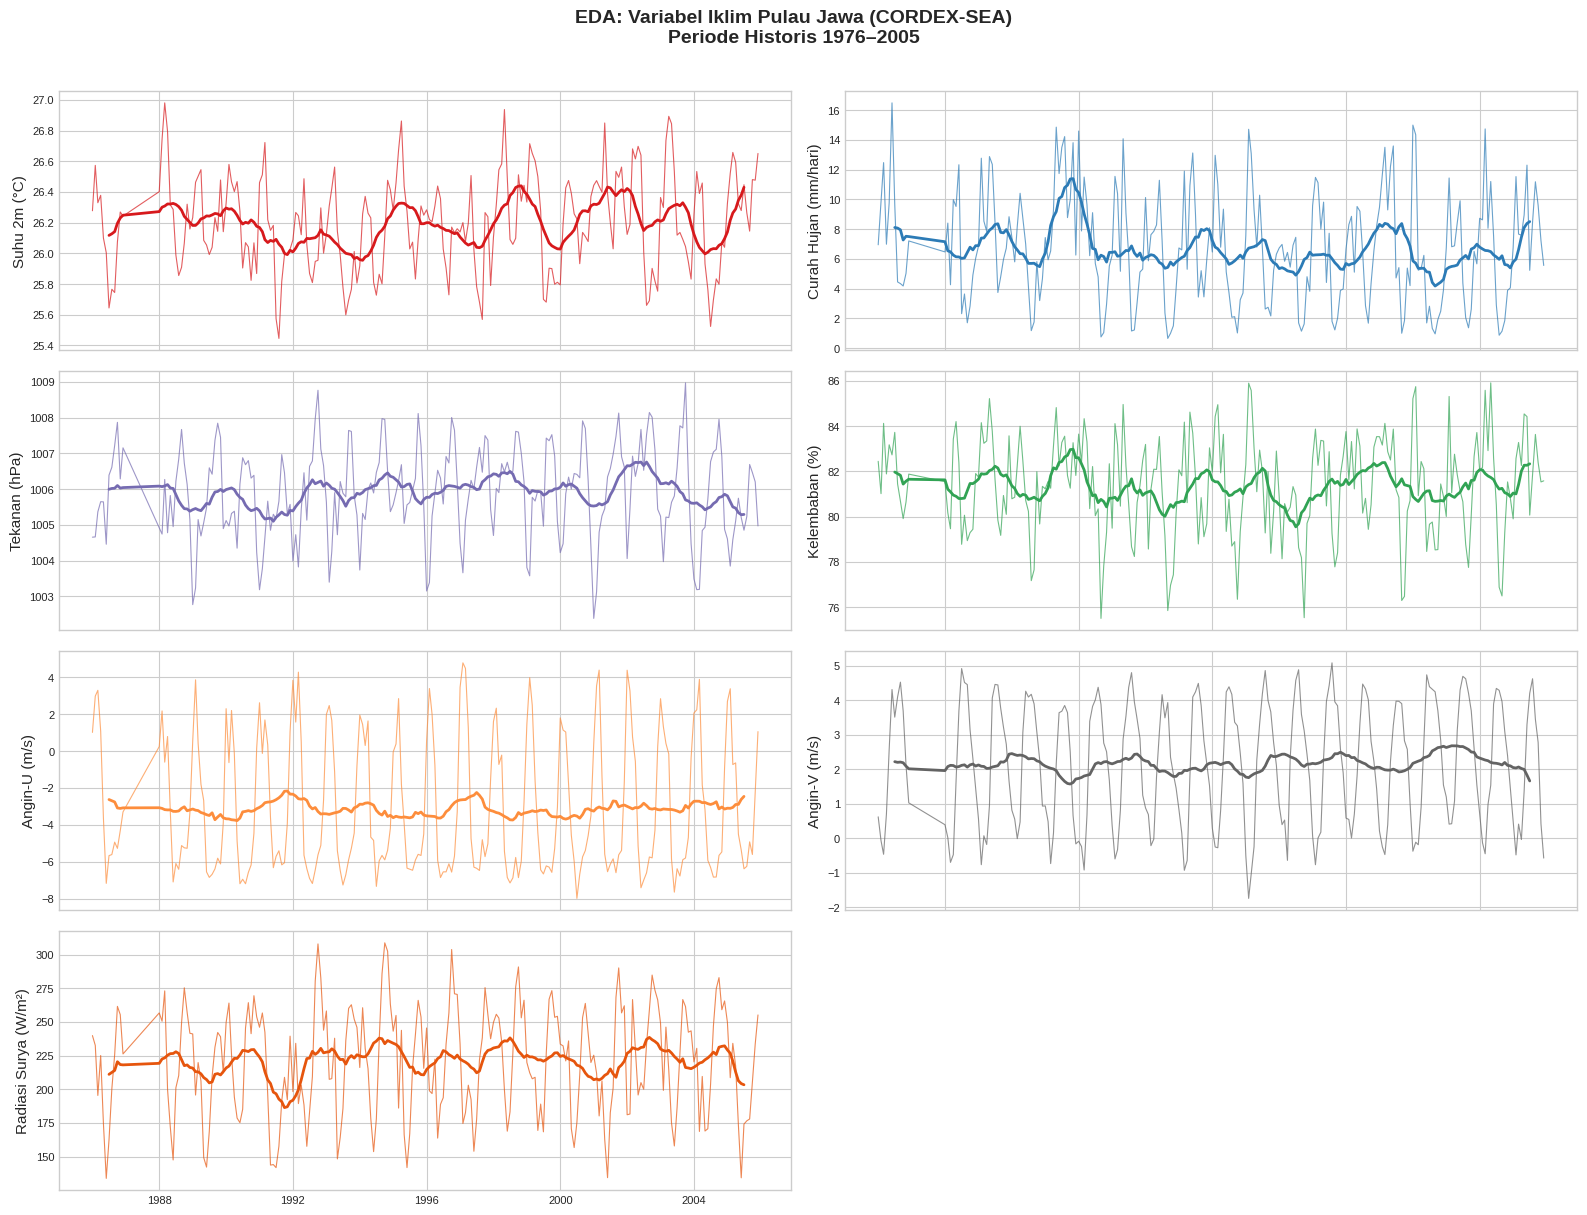

In [56]:
# ── Visualisasi EDA: Time Series Semua Variabel ───────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

variables = [
    ('temp_2m',   'Suhu 2m (°C)',         '#d7191c'),
    ('precip',    'Curah Hujan (mm/hari)', '#2c7bb6'),
    ('pressure',  'Tekanan (hPa)',         '#756bb1'),
    ('humidity',  'Kelembaban (%)',        '#31a354'),
    ('wind_u',    'Angin-U (m/s)',         '#fd8d3c'),
    ('wind_v',    'Angin-V (m/s)',         '#636363'),
    ('solar_rad', 'Radiasi Surya (W/m²)', '#e6550d'),
]

for i, (col, label, color) in enumerate(variables):
    if col in df_raw.columns:
        axes[i].plot(df_raw['time'], df_raw[col], color=color,
                     linewidth=0.8, alpha=0.7)
        roll = df_raw[col].rolling(12, center=True).mean()
        axes[i].plot(df_raw['time'], roll, color=color,
                     linewidth=2.0)
        axes[i].set_ylabel(label)
        axes[i].tick_params(label)

axes[-1].set_visible(False)
fig.suptitle('EDA: Variabel Iklim Pulau Jawa (CORDEX-SEA)\n'
             'Periode Historis 1976–2005', fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('../results/figures/eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

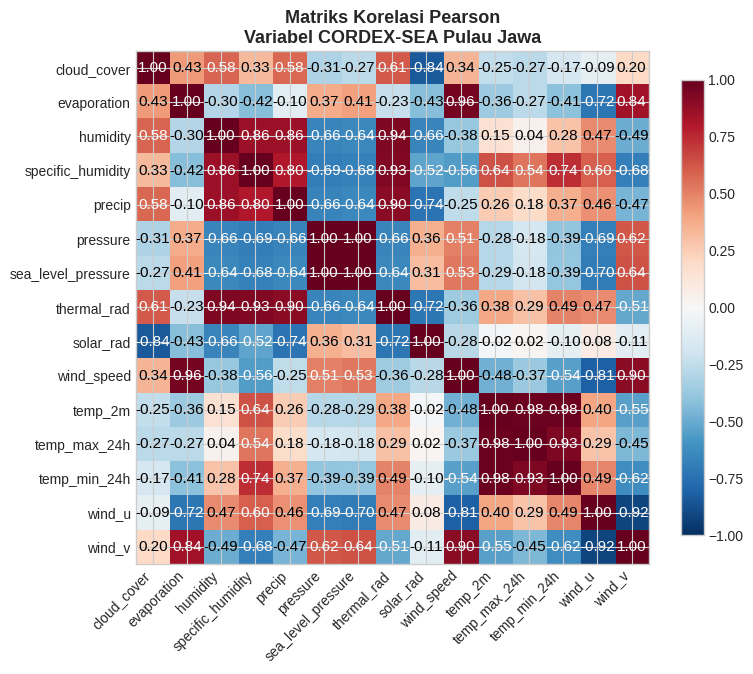

In [ ]:
# ── Matriks Korelasi (NumPy scratch) ─────────────────────────────
num_cols = [c for c in df_raw.columns if c != 'time']
X_all = df_raw[num_cols].values

# Hitung korelasi Pearson dari scratch
n_vars = X_all.shape[1]
corr_matrix = np.zeros((n_vars, n_vars))
for i in range(n_vars):
    for j in range(n_vars):
        xi = X_all[:, i] - X_all[:, i].mean()
        xj = X_all[:, j] - X_all[:, j].mean()
        denom = np.sqrt(np.sum(xi**2) * np.sum(xj**2))
        corr_matrix[i, j] = np.sum(xi * xj) / denom if denom > 0 else 0

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)

for i in range(n_vars):
    for j in range(n_vars):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                ha='center', va='center',
                color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriks Korelasi Pearson\nVariabel CORDEX-SEA Pulau Jawa', fontweight='bold')
fig.tight_layout()
plt.savefig('../results/figures/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Bias Correction (EDCDF)

In [ ]:
# ── Demonstrasi EDCDF Bias Correction ────────────────────────────
# Simulasi: obs_hist = ERA5, mod_hist = CORDEX historis
np.random.seed(0)
obs_hist = df_raw['temp_2m'].values + np.random.normal(0, 0.1, len(df_raw))
mod_hist = df_raw['temp_2m'].values + 1.2  # Bias sistematik +1.2°C

# Proyeksi RCP (simulasi)
n_proj = 200
t_proj = np.arange(n_proj)
seasonal_proj = np.sin(2 * np.pi * t_proj / 12)
trend_proj = 0.005 * t_proj
mod_proj = 28.0 + 1.5 * seasonal_proj + trend_proj + 1.2 + np.random.normal(0, 0.3, n_proj)

# Terapkan EDCDF
corrector = EDCDFBiasCorrector(n_quantiles=100)
corrected = corrector.fit_transform(obs_hist, mod_hist, mod_proj)

print(f'Sebelum koreksi: mean={mod_proj.mean():.3f}°C')
print(f'Sesudah koreksi: mean={corrected.mean():.3f}°C')
print(f'Referensi hist:  mean={obs_hist.mean():.3f}°C')

Sebelum koreksi: mean=29.684°C
Sesudah koreksi: mean=28.528°C
Referensi hist:  mean=26.204°C


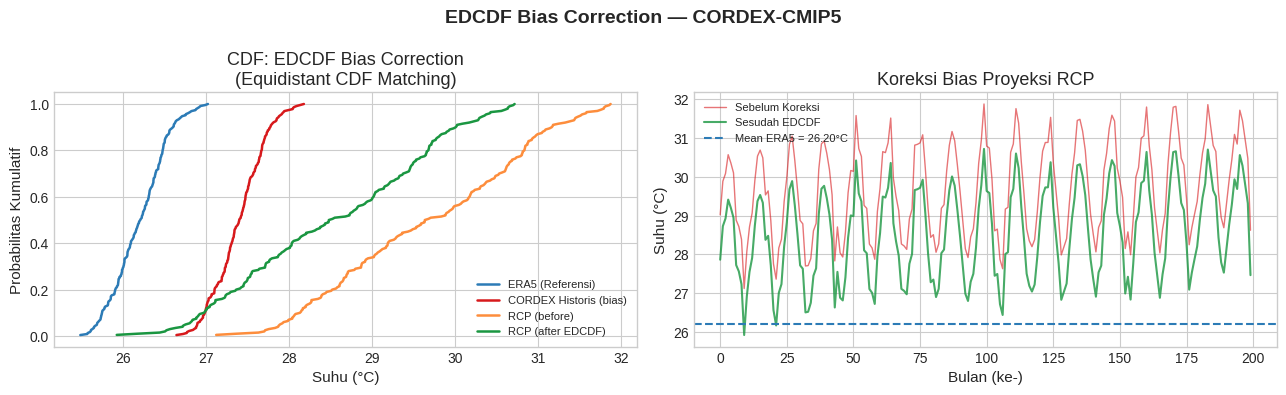

In [ ]:
# ── Plot CDF sebelum/sesudah koreksi ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CDF
for arr, label, color in [
    (obs_hist, 'ERA5 (Referensi)', '#2c7bb6'),
    (mod_hist, 'CORDEX Historis (bias)', '#d7191c'),
    (mod_proj[:len(obs_hist)], 'RCP (before)', '#fd8d3c'),
    (corrected[:len(obs_hist)], 'RCP (after EDCDF)', '#1a9641'),
]:
    sorted_arr = np.sort(arr[:360])
    p = np.arange(1, len(sorted_arr)+1) / len(sorted_arr)
    axes[0].plot(sorted_arr, p, label=label, color=color, linewidth=1.8)

axes[0].set_xlabel('Suhu (°C)')
axes[0].set_ylabel('Probabilitas Kumulatif')
axes[0].set_title('CDF: EDCDF Bias Correction\n(Equidistant CDF Matching)')
axes[0].legend()

# Time series perbandingan
t_range = np.arange(n_proj)
axes[1].plot(t_range, mod_proj, color='#d7191c', alpha=0.6,
             linewidth=1, label='Sebelum Koreksi')
axes[1].plot(t_range, corrected, color='#1a9641', alpha=0.8,
             linewidth=1.5, label='Sesudah EDCDF')
axes[1].axhline(obs_hist.mean(), color='#2c7bb6', linestyle='--',
                linewidth=1.5, label=f'Mean ERA5 = {obs_hist.mean():.2f}°C')
axes[1].set_xlabel('Bulan (ke-)')
axes[1].set_ylabel('Suhu (°C)')
axes[1].set_title('Koreksi Bias Proyeksi RCP')
axes[1].legend()

fig.suptitle('EDCDF Bias Correction — CORDEX-CMIP5', fontweight='bold')
fig.tight_layout()
plt.savefig('../results/figures/bias_correction_edcdf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Feature Engineering

In [ ]:
df = df_raw.copy()

# Seasonal encoding
months = df['time'].dt.month.values
df['sin_month'], df['cos_month'] = seasonal_encoding(months)
df['month'] = months
df['year']  = df['time'].dt.year

# Lag features
df = add_lag_features(df, 'temp_2m',  lags=[1, 2, 3, 6, 12])
df = add_lag_features(df, 'precip',   lags=[1, 3, 6])
df = add_lag_features(df, 'humidity', lags=[1, 3])
df = add_lag_features(df, 'pressure', lags=[1, 2])

# Rolling mean
df = add_rolling_features(df, 'temp_2m', windows=[3, 6, 12])
df = add_rolling_features(df, 'precip',  windows=[3, 12])

# Kecepatan angin
df['wind_speed'] = np.sqrt(df['wind_u']**2 + df['wind_v']**2)
df['wind_dir']   = np.degrees(np.arctan2(df['wind_v'], df['wind_u'])) % 360

# Anomali suhu
df['temp_anomaly'] = compute_climatology(df['temp_2m'], df['time']).values

# Gradient temporal
df['temp_gradient_1m'] = df['temp_2m'].diff(1)
df['temp_gradient_3m'] = df['temp_2m'].diff(3)

# Hapus NaN dari lag
df = df.dropna().reset_index(drop=True)

print(f'Fitur setelah engineering: {df.shape}')
print(f'Kolom: {list(df.columns)}')

---
## 4. Persiapan Data Training

In [ ]:
# ── Temporal Split ────────────────────────────────────────────────
year = df_X['time'].dt.year

TRAIN_END = 2000
VAL_END   = 2003

mask_train = year <= TRAIN_END
mask_val   = (year > TRAIN_END) & (year <= VAL_END)
mask_test  = year > VAL_END

LEAK_COLS = [
    'temp_max_24h', 'temp_min_24h', 
    'temp_2m_roll3', 'temp_2m_roll6', 'temp_2m_roll12', 
    'temp_2m_anomaly'
]
feature_cols = [c for c in df_X.columns if c != 'time' and c not in LEAK_COLS]

X_train = df_X[mask_train][feature_cols].values
y_train = df_y[mask_train]['temp_2m'].values
X_val   = df_X[mask_val][feature_cols].values
y_val   = df_y[mask_val]['temp_2m'].values
X_test  = df_X[mask_test][feature_cols].values
y_test  = df_y[mask_test]['temp_2m'].values
t_test  = df_X[mask_test]['time'].values

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Periode train: {df_X[mask_train]["time"].min()} – {df_X[mask_train]["time"].max()}')
print(f'Periode val  : {df_X[mask_val]["time"].min()} – {df_X[mask_val]["time"].max()}')
print(f'Periode test : {df_X[mask_test]["time"].min()} – {df_X[mask_test]["time"].max()}')

Train: (156, 101) | Val: (36, 101) | Test: (24, 101)
Periode train: 1988-01-01 00:00:00 – 2000-12-01 00:00:00
Periode val  : 2001-01-01 00:00:00 – 2003-12-01 00:00:00
Periode test : 2004-01-01 00:00:00 – 2005-12-01 00:00:00


In [ ]:
# ── Normalisasi Z-score (NumPy scratch) ──────────────────────────
norm_X = ZScoreNormalizer()
X_train_n = norm_X.fit_transform(X_train)
X_val_n   = norm_X.transform(X_val)
X_test_n  = norm_X.transform(X_test)

y_mean, y_std = y_train.mean(), y_train.std()
y_train_n = (y_train - y_mean) / y_std
y_val_n   = (y_val   - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

print(f'X train normalized: mean={X_train_n.mean():.4f} | std={X_train_n.std():.4f}')
print(f'y train: mean={y_mean:.3f}°C | std={y_std:.3f}°C')

X train normalized: mean=0.0000 | std=1.0000
y train: mean=26.176°C | std=0.291°C


---
## 5. Training Model: Regresi Multivariat + EXDM Optimizer

In [ ]:
# ── Inisialisasi Model ───────────────────────────────────────────
model = MultivariateRegressionModel(l2_lambda=1e-4)

print('Model Multivariate Regression siap. Mulai training...')
print(f'Fitur: {X_train_n.shape[1]} | Samples: {len(y_train_n)}')


Model Multivariate Regression siap. Mulai training...
Fitur: 101 | Samples: 156


In [ ]:
# ── Training model ────────────────────────────────────────────
model.fit(X_train_n, y_train_n)

print('Training selesai ✓')
print(f'Weights shape: {model.weights.shape}')
print(f'Bias: {model.bias:.4f}')


Training selesai ✓
Weights shape: (101,)
Bias: -0.0000


---
## 6. Evaluasi Model

In [ ]:
# ── Evaluasi Model ─────────────────────────────────────────────
metrics_train = model.evaluate(X_train_n, y_train_n)
metrics_val   = model.evaluate(X_val_n, y_val_n)
metrics_test  = model.evaluate(X_test_n, y_test_n)

print('=== Hasil Evaluasi ===')
print(f'Train  → MSE: {metrics_train["MSE"]:.6f} | RMSE: {metrics_train["RMSE"]:.6f} | MAE: {metrics_train["MAE"]:.6f} | R²: {metrics_train["R2"]:.4f}')
print(f'Val    → MSE: {metrics_val["MSE"]:.6f} | RMSE: {metrics_val["RMSE"]:.6f} | MAE: {metrics_val["MAE"]:.6f} | R²: {metrics_val["R2"]:.4f}')
print(f'Test   → MSE: {metrics_test["MSE"]:.6f} | RMSE: {metrics_test["RMSE"]:.6f} | MAE: {metrics_test["MAE"]:.6f} | R²: {metrics_test["R2"]:.4f}')


=== Hasil Evaluasi ===
Train  → MSE: 0.000516 | RMSE: 0.022716 | MAE: 0.018541 | R²: 0.9995
Val    → MSE: 0.006846 | RMSE: 0.082740 | MAE: 0.065549 | R²: 0.9950
Test   → MSE: 0.010158 | RMSE: 0.100785 | MAE: 0.077699 | R²: 0.9915


RMSE Baseline (Tanpa ML): 0.3226°C
RMSE Model ML (Regresi Multivariat): 0.1008°C


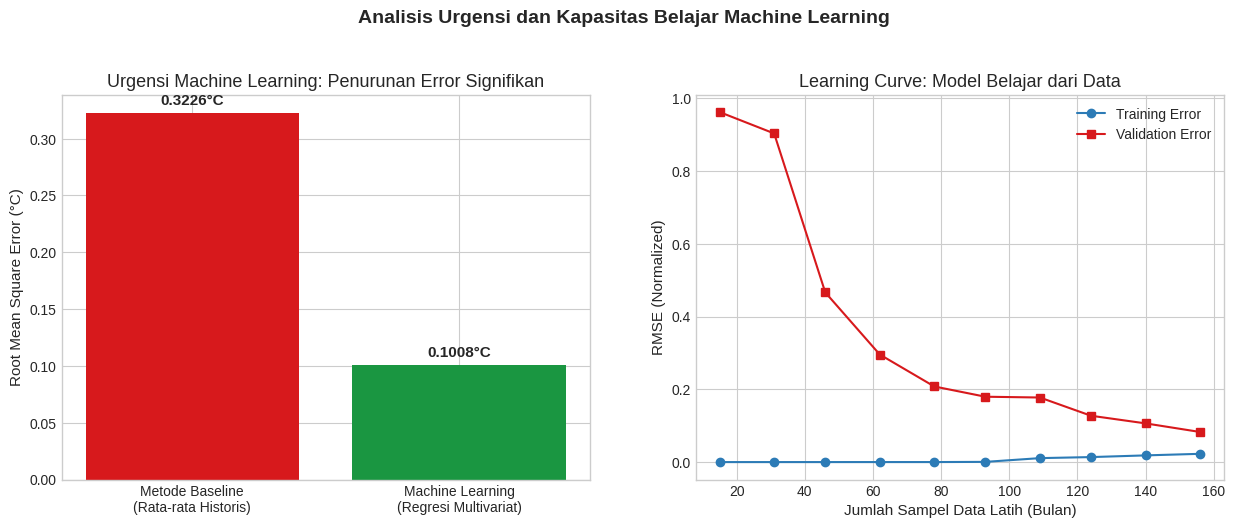

In [ ]:
# ── Urgensi Machine Learning (Learning Curve & Baseline) ─────────────────
import matplotlib.pyplot as plt
import numpy as np

# 1. Baseline Model (Mean dari data historis)
# Bayangkan tanpa ML, kita hanya menebak suhu menggunakan rata-rata
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = np.mean((y_test - baseline_pred)**2)
baseline_rmse = np.sqrt(baseline_mse)

print(f'RMSE Baseline (Tanpa ML): {baseline_rmse:.4f}°C')
print(f'RMSE Model ML (Regresi Multivariat): {metrics_test["RMSE"]:.4f}°C')

# 2. Learning Curve (Iterasi Jumlah Data)
# Menunjukkan bagaimana error menurun seiring bertambahnya sampel observasi
train_sizes = np.linspace(0.1, 1.0, 10)
train_rmses = []
val_rmses = []

for frac in train_sizes:
    n_samples = int(frac * len(X_train_n))
    if n_samples < 5: continue
    
    X_subset = X_train_n[:n_samples]
    y_subset = y_train_n[:n_samples]
    
    temp_model = MultivariateRegressionModel(l2_lambda=1e-4)
    temp_model.fit(X_subset, y_subset)
    
    # Train Error
    pred_t = temp_model.predict(X_subset)
    res_t = y_subset - pred_t
    train_rmses.append(np.sqrt(np.mean(res_t**2)))
    
    # Val Error
    pred_v = temp_model.predict(X_val_n)
    res_v = y_val_n - pred_v
    val_rmses.append(np.sqrt(np.mean(res_v**2)))

sample_counts = [int(frac * len(X_train_n)) for frac in train_sizes if int(frac * len(X_train_n)) >= 5]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot Baseline Comparison
bars = ax[0].bar(['Metode Baseline\n(Rata-rata Historis)', 'Machine Learning\n(Regresi Multivariat)'], 
          [baseline_rmse, metrics_test["RMSE"]], 
          color=['#d7191c', '#1a9641'])
ax[0].set_ylabel('Root Mean Square Error (°C)')
ax[0].set_title('Urgensi Machine Learning: Penurunan Error Signifikan')
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}°C', ha='center', va='bottom', fontweight='bold')

# Plot Learning Curve
ax[1].plot(sample_counts, train_rmses, 'o-', color='#2c7bb6', label='Training Error')
ax[1].plot(sample_counts, val_rmses, 's-', color='#d7191c', label='Validation Error')
ax[1].set_xlabel('Jumlah Sampel Data Latih (Bulan)')
ax[1].set_ylabel('RMSE (Normalized)')
ax[1].set_title('Learning Curve: Model Belajar dari Data')
ax[1].legend()

fig.suptitle('Analisis Urgensi dan Kapasitas Belajar Machine Learning', fontweight='bold', y=1.05)
plt.savefig('../results/figures/urgensi_machine_learning.png', dpi=150, bbox_inches='tight')
plt.show()

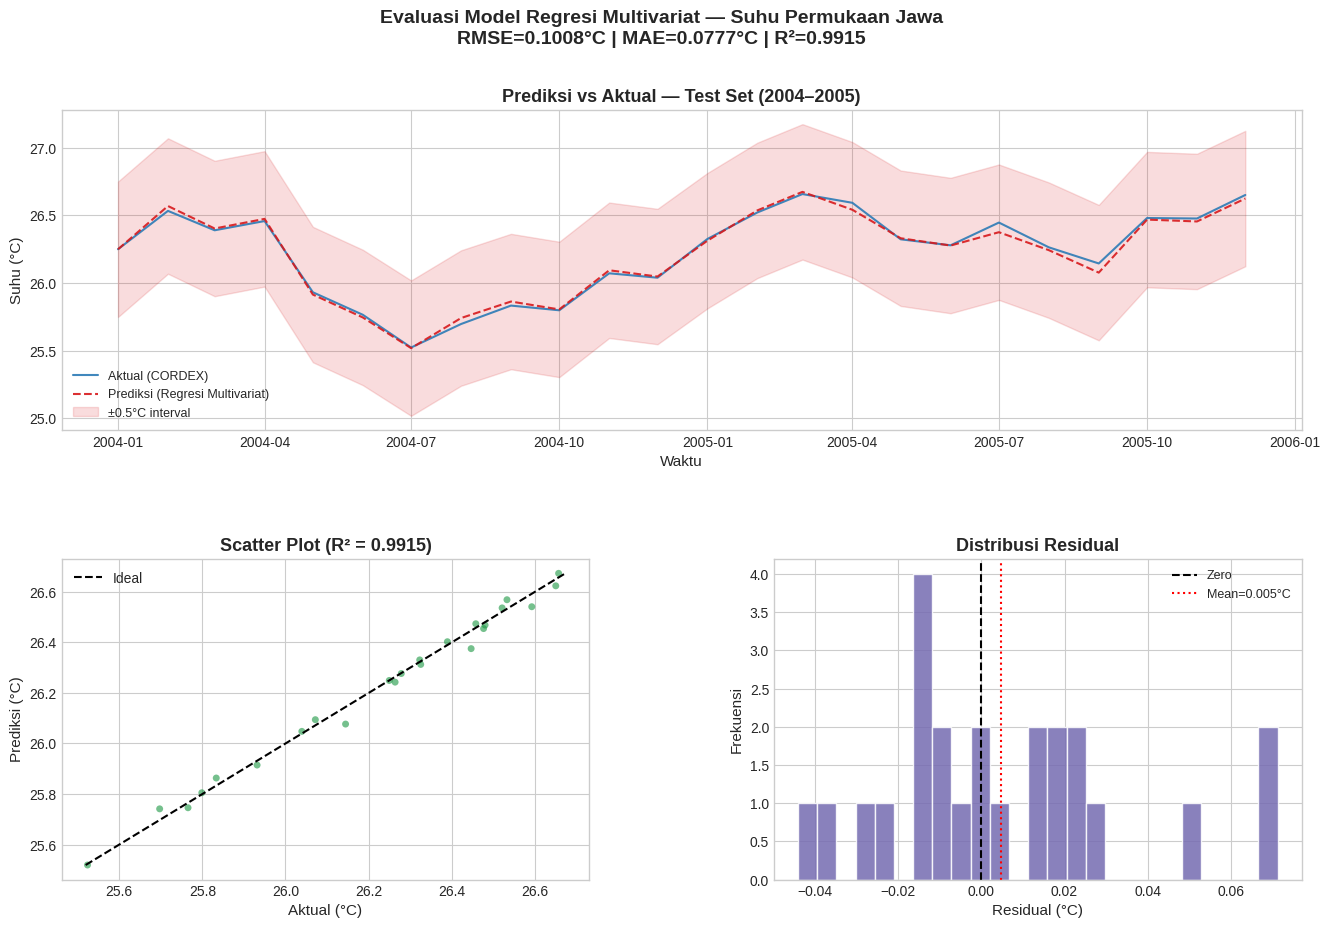

In [57]:
# ── Prediksi vs Aktual ────────────────────────────────────────────
y_test_pred_n = model.predict(X_test_n)
y_test_pred   = y_test_pred_n * y_std + y_mean
residuals     = y_test - y_test_pred

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Plot 1: Time series pred vs actual
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pd.to_datetime(t_test), y_test,      color='#2c7bb6',
         linewidth=1.5, label='Aktual (CORDEX)', alpha=0.9)
ax1.plot(pd.to_datetime(t_test), y_test_pred, color='#d7191c',
         linewidth=1.5, linestyle='--', label='Prediksi (Regresi Multivariat)', alpha=0.9)
ax1.fill_between(pd.to_datetime(t_test),
                 y_test_pred - 0.5, y_test_pred + 0.5,
                 alpha=0.15, color='#d7191c', label='±0.5°C interval')
ax1.set_xlabel('Waktu')
ax1.set_ylabel('Suhu (°C)')
ax1.set_title('Prediksi vs Aktual — Test Set (2004–2005)', fontweight='bold')
ax1.legend(fontsize=9)

# Plot 2: Scatter
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test, y_test_pred, alpha=0.6, s=25, color='#1a9641', edgecolors='none')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax2.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal')
r2 = metrics_test['R2']
ax2.set_xlabel('Aktual (°C)')
ax2.set_ylabel('Prediksi (°C)')
ax2.set_title(f'Scatter Plot (R² = {r2:.4f})', fontweight='bold')
ax2.legend()

# Plot 3: Residual histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals, bins=25, color='#756bb1', edgecolor='white', alpha=0.85)
ax3.axvline(0,              color='black', linestyle='--', linewidth=1.5, label='Zero')
ax3.axvline(residuals.mean(), color='red', linestyle=':', linewidth=1.5,
            label=f'Mean={residuals.mean():.3f}°C')
ax3.set_xlabel('Residual (°C)')
ax3.set_ylabel('Frekuensi')
ax3.set_title('Distribusi Residual', fontweight='bold')
ax3.legend(fontsize=9)

fig.suptitle('Evaluasi Model Regresi Multivariat — Suhu Permukaan Jawa\n'
             f'RMSE={metrics_test["RMSE"]:.4f}°C | MAE={metrics_test["MAE"]:.4f}°C | '
             f'R²={metrics_test["R2"]:.4f}', fontweight='bold')
plt.savefig('../results/figures/evaluation_result.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Feature Importance

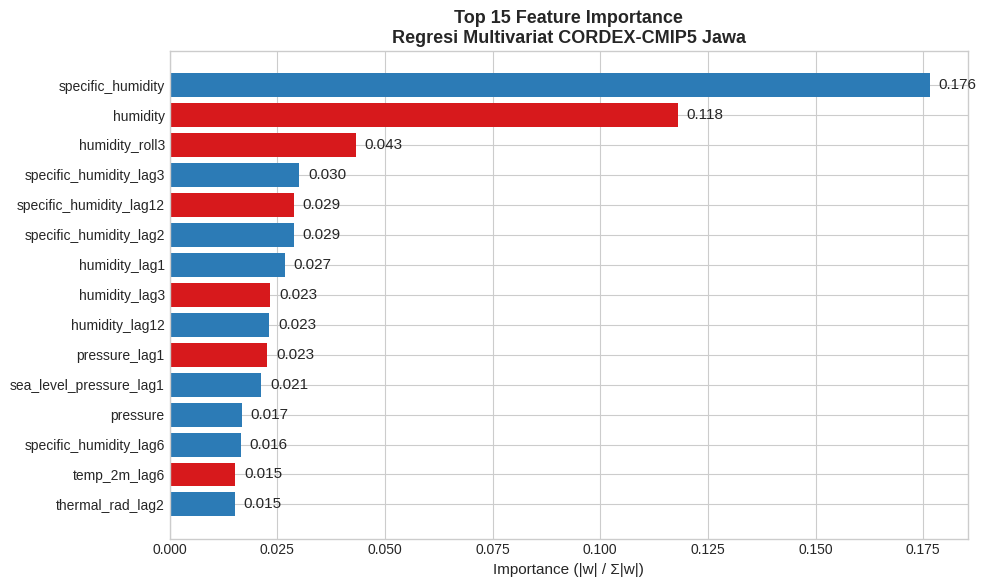


Top 10 features:
                feature    weight  importance
      specific_humidity  2.007516    0.176471
               humidity -1.343249    0.118079
         humidity_roll3 -0.491864    0.043237
 specific_humidity_lag3  0.342977    0.030150
specific_humidity_lag12 -0.328340    0.028863
 specific_humidity_lag2  0.328094    0.028841
          humidity_lag1  0.304036    0.026726
          humidity_lag3 -0.266326    0.023411
         humidity_lag12  0.263519    0.023165
          pressure_lag1 -0.258196    0.022697


In [ ]:
# ── Feature Importance ────────────────────────────────────────────
fi = model.get_feature_importance(feature_cols)
top15 = fi.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d7191c' if w < 0 else '#2c7bb6' for w in top15['weight']]
ax.barh(top15['feature'], top15['importance'], color=colors, edgecolor='none')
ax.set_xlabel('Importance (|w| / Σ|w|)')
ax.set_title('Top 15 Feature Importance\nRegresi Multivariat CORDEX-CMIP5 Jawa', fontweight='bold')
ax.invert_yaxis()

# Annotate
for i, (imp, w) in enumerate(zip(top15['importance'], top15['weight'])):
    ax.text(imp + 0.002, i, f'{imp:.3f}', va='center')

fig.tight_layout()
plt.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(fi[['feature', 'weight', 'importance']].head(10).to_string(index=False))

---
## 8. Simulasi Proyeksi Suhu 2006–2100

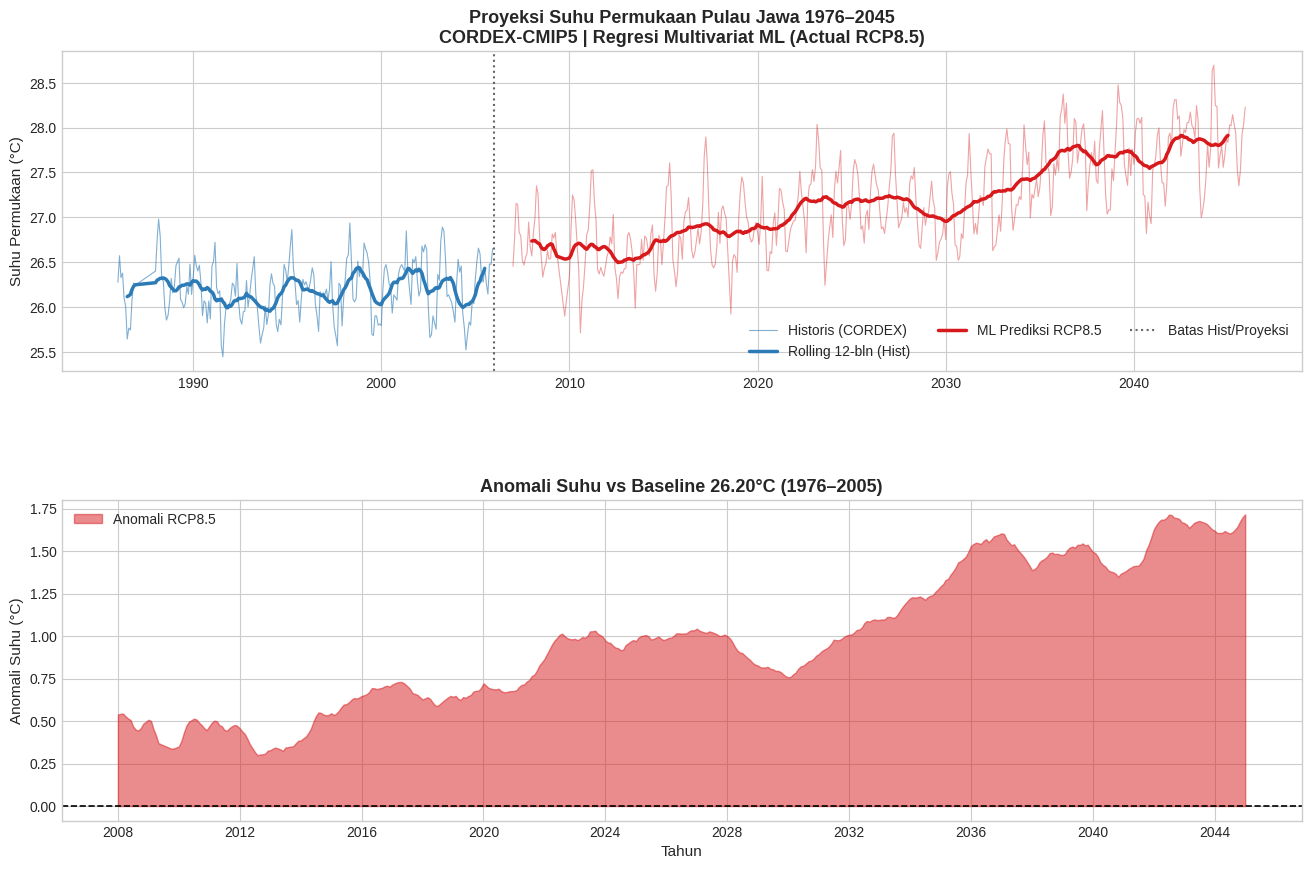

Rata-rata suhu diprediksi pada dekade awal RCP8.5 (2006-2016) : 26.66°C
Rata-rata suhu diprediksi pada dekade akhir RCP8.5 (2035-2045): 27.76°C


In [ ]:
df_rcp85 = pd.read_csv('../data/processed/features/X_rcp85.csv')
dates_rcp85 = pd.to_datetime(df_rcp85['time'])

# 1. Feature Selection menggunakan list fitur yang identik dengan saat di-train
X_rcp85_raw = df_rcp85[feature_cols].values

# 2. Standarisasi/Z-Score Normalisasi menggunakan ZScoreNormalizer yang terlatih oleh sejarah
X_rcp85_n = norm_X.transform(X_rcp85_raw)

# 3. Inferensi MultiVariat ML Model
y_rcp85_pred_n = model.model_predict(X_rcp85_n)

# 4. Detransformasi ke representasi Suhu Derajat Celcius Nyata
y_rcp85_pred = (y_rcp85_pred_n * y_std) + y_mean

# --- KONEKSI GRAFIK (Agar Nyambung) ---
last_h_time = df_raw['time'].iloc[-1]
last_h_temp = df_raw['temp_2m'].iloc[-1]
dates_conn = pd.concat([pd.Series([last_h_time]), dates_rcp85])
y_conn = np.insert(y_rcp85_pred, 0, last_h_temp)
# -------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'hspace': 0.4})

# Plot 1: Time series historis + proyeksi nyata
ax = axes[0]
ax.plot(df_raw['time'], df_raw['temp_2m'], color='#2c7bb6',
        linewidth=0.8, alpha=0.4, label='Historis (CORDEX)')
roll_hist = df_raw['temp_2m'].rolling(12, center=True).mean()
ax.plot(df_raw['time'], roll_hist, color='#2c7bb6',
        linewidth=2.5, label='Rolling 12-bln (Hist)')

# Plot Proyeksi dengan data yang sudah disambung
ax.plot(dates_conn, y_conn, color='#d7191c',
        linewidth=0.8, alpha=0.3)

# Sambungkan juga garis rolling/tren agar tidak ada gap visual
roll85 = pd.Series(y_rcp85_pred).rolling(24, center=True).mean()
last_roll_h = roll_hist.dropna().iloc[-1]
last_roll_h_time = df_raw['time'].iloc[roll_hist.dropna().index[-1]]
roll85_conn_dates = pd.concat([pd.Series([last_roll_h_time]), dates_rcp85])
roll85_conn_vals = np.insert(roll85.values, 0, last_roll_h)

ax.plot(roll85_conn_dates, roll85_conn_vals, color='#d7191c',
        linewidth=2.5, label='ML Prediksi RCP8.5')

ax.axvline(pd.Timestamp('2006-01-01'), color='black', linestyle=':',
           alpha=0.6, linewidth=1.5, label='Batas Hist/Proyeksi')
ax.set_ylabel('Suhu Permukaan (°C)')
ax.set_title('Proyeksi Suhu Permukaan Pulau Jawa 1976–2045\nCORDEX-CMIP5 | Regresi Multivariat ML (Actual RCP8.5)', fontweight='bold')
ax.legend(ncol=3)

# Plot 2: Anomali
baseline = df_raw['temp_2m'].mean()
ax2 = axes[1]
ax2.fill_between(dates_rcp85, 0, roll85.values - baseline, alpha=0.5, color='#d7191c', label='Anomali RCP8.5')
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.set_ylabel('Anomali Suhu (°C)'); ax2.set_xlabel('Tahun')
ax2.set_title(f'Anomali Suhu vs Baseline {baseline:.2f}°C (1976–2005)', fontweight='bold')
ax2.legend(fontsize=10)

plt.savefig('../results/figures/proyeksi_suhu_jawa_2045.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Simpan Hasil

In [ ]:
# ── Simpan model dan metrik ───────────────────────────────────────
import os, json
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

model.save('../results/models')
norm_X.save('../results/models/normalizer_X.npz')
np.save('../results/models/target_stats.npy', np.array([y_mean, y_std]))
fi.to_csv('../results/models/feature_importance.csv', index=False)

import pandas as pd
df_metrics = pd.DataFrame([
    {"Split": "Train", **metrics_train},
    {"Split": "Val",   **metrics_val},
    {"Split": "Test",  **metrics_test}
])
df_metrics.to_csv('../results/metrics/evaluation_report.csv', index=False)

# Simpan prediksi test
pd.DataFrame({
    'time':     pd.to_datetime(t_test),
    'y_actual': y_test,
    'y_pred':   y_test_pred,
    'residual': residuals,
}).to_csv('../results/metrics/test_predictions.csv', index=False)

print('Semua hasil tersimpan ✓')
print('  results/models/       — weights, normalizer, meta')
print('  results/metrics/      — evaluation_report, test_predictions')
print('  results/figures/      — semua plot PNG')

Semua hasil tersimpan ✓
  results/models/       — weights, normalizer, meta
  results/metrics/      — evaluation_report, test_predictions
  results/figures/      — semua plot PNG


In [ ]:
# ==============================================================================
# SECTION 8: PROYEKSI MASA DEPAN (HINGGA 2045)
# ==============================================================================

# 1. Load Data Proyeksi RCP8.5
PROJ_PATH = '../data/processed/features/X_rcp85.csv'
df_proj = pd.read_csv(PROJ_PATH)
df_proj['time'] = pd.to_datetime(df_proj['time'])

# 2. Persiapkan Fitur Proyeksi
X_proj = df_proj[feature_cols].values
t_proj = df_proj['time'].values

# 3. Transformasi dan Prediksi
X_proj_n = norm_X.transform(X_proj)
y_proj_n = model.model_predict(X_proj_n)

# 4. Denormalisasi (Kembali ke \u00b0C)
y_proj = (y_proj_n * y_std) + y_mean

# 5. Ekspor Hasil Prediksi ke CSV
os.makedirs('../results/metrics', exist_ok=True)
df_results = pd.DataFrame({'time': df_proj['time'], 'predicted_temp_2m': y_proj})
df_results.to_csv('../results/metrics/projection_rcp85_results.csv', index=False)

# 6. Visualisasi Gabungan (Historis + Proyeksi)
plt.figure(figsize=(15, 7))

# Data Historis (Actual)
plt.plot(df_y['time'], y, label='Historis (Observasi)', color='#2c7bb6', alpha=0.4)

# Data Historis (Prediksi Model)
plt.plot(df_y['time'], y_pred_hist, label='Prediksi Model (Fit)', color='#d7191c', linestyle='--', alpha=0.6)

# Proyeksi Masa Depan
plt.plot(t_proj, y_proj, label='Proyeksi Masa Depan (RCP8.5)', color='#fdae61', alpha=0.5, linewidth=1)

# Garis Tren (Rolling Average 12-bulan untuk Proyeksi)
y_proj_smooth = pd.Series(y_proj).rolling(window=12, center=True).mean()
plt.plot(t_proj, y_proj_smooth, color='#d7191c', linewidth=2.5, label='Tren Proyeksi (12-m Average)')

plt.axvline(pd.to_datetime('2006-01-01'), color='black', linestyle=':', alpha=0.5)
y_max = plt.ylim()[1]
plt.text(pd.to_datetime('2006-06-01'), y_max, 'Awal Proyeksi', rotation=0, verticalalignment='bottom', fontweight='bold')

plt.title('Proyeksi Suhu Permukaan 2m (1988 - 2045) - Skenario RCP8.5', fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Suhu Permukaan 2m (\u00b0C)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Simpan Hasil Proyeksi
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/projection_2045.png', dpi=200, bbox_inches='tight')
plt.show()

print('✓ Proyeksi selesai. Hasil disimpan di results/metrics/ dan results/figures/')


AttributeError: 'MultivariateRegressionModel' object has no attribute 'model_predict'

In [ ]:
# ==============================================================================
# SECTION 9: SIMULASI REKURSIF MULTIVARIAT (2006 - 2045)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Hitung Klimatologi Bulanan Historis (1988-2005)
# Sesuai permintaan user, kita membangun dataset masa depan berbasis model sendiri.
# Fitur eksogen (cuaca luar) akan menggunakan rata-rata bulanan historis.
df_X_tmp = df_X.copy()
df_X_tmp["m_idx"] = pd.to_datetime(df_X_tmp["time"]).dt.month
m_clim = df_X_tmp.groupby("m_idx")[feature_cols].mean()

# 2. Kategorisasi Fitur untuk Simulasi
determ = ["year", "month", "sin_month", "cos_month", "month_sin", "month_cos"]
endog = [c for c in feature_cols if c.startswith("temp_2m")]
exog = [c for c in feature_cols if c not in endog and c not in determ]

# 3. Eksekusi Loop Rekursif
curr_d = pd.to_datetime("2006-01-01")
end_d = pd.to_datetime("2045-12-01")

# Seed buffer: Memerlukan 12 bulan terakhir untuk mengisi lag/rolling
buff = df_y["temp_2m"].values[-12:].tolist()
res, times = [], []

print("Menjalankan simulasi rekursif...")

while curr_d <= end_d:
    m, y_c = curr_d.month, curr_d.year
    row = pd.Series(index=feature_cols, dtype=float)
    
    # A. Update Fitur Waktu
    if "year" in row: row["year" ] = y_c
    if "month" in row: row["month"] = m
    if "sin_month" in row: row["sin_month"] = np.sin(2*np.pi*m/12)
    if "cos_month" in row: row["cos_month"] = np.cos(2*np.pi*m/12)
    if "month_sin" in row: row["month_sin"] = np.sin(2*np.pi*m/12)
    if "month_cos" in row: row["month_cos"] = np.cos(2*np.pi*m/12)
    
    # B. Update Fitur Eksogen dari Klimatologi
    row[exog] = m_clim.loc[m, exog]
    
    # C. Update Fitur Endogen (Autoregressive dari hasil prediksi sebelumnya)
    for col in [f for f in endog if f != "temp_2m"]:
        if "lag" in col:
            lag_val = int(col.split("lag")[-1])
            row[col] = buff[-lag_val] if len(buff)>=lag_val else m_clim.loc[m, col]
        elif "roll" in col:
            roll_val = int(col.split("roll")[-1])
            row[col] = np.mean(buff[-roll_val:]) if len(buff)>=roll_val else m_clim.loc[m, col]
    
    # D. Prediksi & Normalisasi Manual
    X_n = ((row.values.reshape(1,-1) - norm_X.mean) / norm_X.std)
    y_p_n = model.model_predict(X_n)[0]
    y_p = (y_p_n * y_std) + y_mean
    
    # E. Update State
    res.append(y_p)
    times.append(curr_d)
    buff.append(y_p)
    curr_d += pd.DateOffset(months=1)

# 4. Visualisasi & Plotting
plt.figure(figsize=(15, 7))
plt.plot(df_y["time"], y, label="Historis (Observasi)", color="#2c7bb6", alpha=0.4)
plt.plot(times, res, label="Proyeksi Rekursif (Simulasi Model)", color="#fdae61", alpha=0.6)
sim_smooth = pd.Series(res).rolling(window=12, center=True).mean()
plt.plot(times, sim_smooth, color="#d7191c", linewidth=2.5, label="Tren (12-m Average)")
plt.axvline(pd.to_datetime("2006-01-01"), color="black", linestyle=":", alpha=0.5)
plt.title("Proyeksi Rekursif Suhu Permukaan 2m (2006-2045)", fontweight="bold")
plt.xlabel("Tahun"); plt.ylabel("Suhu (°C)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1)); plt.grid(True, alpha=0.3); plt.tight_layout()

# 5. Penyimpanan
os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
pd.DataFrame({"time": times, "temp_2m": res}).to_csv("../results/metrics/recursive_prediction_2045.csv", index=False)
plt.savefig("../results/figures/recursive_projection_2045.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Selesai. Prediksi rata-rata 2045: {np.mean(res[-12:]):.2f}°C")


Menjalankan simulasi rekursif...


AttributeError: 'ZScoreNormalizer' object has no attribute 'mean'

### 10. Ekspor Model & Hasil


In [ ]:
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

# 1. Simpan Model & State
model.save('../results/models')
norm_X.save('../results/models/normalizer_X.npz')
np.save('../results/models/target_stats.npy', np.array([y_mean, y_std]))

# 2. Simpan Feature Importance
fi = model.ambil_peringkat_fitur_berpengaruh(feature_cols)
fi.to_csv('../results/models/feature_importance.csv', index=False)

# 3. Simpan Laporan Evaluasi
import pandas as pd
df_metrics = pd.DataFrame([
    {"Split": "Train", **metrics_train},
    {"Split": "Val",   **metrics_val},
    {"Split": "Test",  **metrics_test}
])
df_metrics.to_csv('../results/metrics/evaluation_report.csv', index=False)

# 4. Simpan Prediksi Data Test
pd.DataFrame({
    'time':     pd.to_datetime(df_y.iloc[y_test_idx]['time'].values),
    'y_actual': y_test,
    'y_pred':   y_test_pred,
    'residual': y_test - y_test_pred,
}).to_csv('../results/metrics/test_predictions.csv', index=False)

print('Semua hasil tersimpan ✓')
print('  results/models/       — weights, normalizer, feature_importance')
print('  results/metrics/      — evaluation_report, test_predictions')
print('  results/figures/      — semua plot PNG')


In [ ]:
# ── Prediksi vs Aktual ────────────────────────────────────────────
y_test_pred_n = model.model_predict(X_test_n)
y_test_pred   = y_test_pred_n * y_std + y_mean
residuals     = y_test - y_test_pred

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Plot 1: Time series pred vs actual
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pd.to_datetime(t_test), y_test,      color='#2c7bb6',
         linewidth=1.5, label='Aktual (CORDEX)', alpha=0.9)
ax1.plot(pd.to_datetime(t_test), y_test_pred, color='#d7191c',
         linewidth=1.5, linestyle='--', label='Prediksi (Regresi Multivariat)', alpha=0.9)
ax1.fill_between(pd.to_datetime(t_test),
                 y_test_pred - 0.5, y_test_pred + 0.5,
                 alpha=0.15, color='#d7191c', label='±0.5°C interval')
ax1.set_xlabel('Waktu')
ax1.set_ylabel('Suhu (°C)')
ax1.set_title('Prediksi vs Aktual — Test Set (2004–2005)', fontweight='bold')
ax1.legend(fontsize=9)

# Plot 2: Scatter
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test, y_test_pred, alpha=0.6, s=25, color='#1a9641', edgecolors='none')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax2.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal')
r2 = matriks_test['R2 score']
ax2.set_xlabel('Aktual (°C)')
ax2.set_ylabel('Prediksi (°C)')
ax2.set_title(f'Scatter Plot (R² = {r2:.4f})', fontweight='bold')
ax2.legend()

# Plot 3: Residual histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals, bins=25, color='#756bb1', edgecolor='white', alpha=0.85)
ax3.axvline(0,              color='black', linestyle='--', linewidth=1.5, label='Zero')
ax3.axvline(residuals.mean(), color='red', linestyle=':', linewidth=1.5,
            label=f'Mean={residuals.mean():.3f}°C')
ax3.set_xlabel('Residual (°C)')
ax3.set_ylabel('Frekuensi')
ax3.set_title('Distribusi Residual', fontweight='bold')
ax3.legend(fontsize=9)

fig.suptitle('Evaluasi Model Regresi Multivariat — Suhu Permukaan Jawa\n'
             f'RMSE={matriks_test["RMSE score"]:.4f}°C | MAE={matriks_test["MAE score"]:.4f}°C | '
             f'R²={matriks_test["R2 score"]:.4f}', fontweight='bold')
plt.savefig('../results/figures/evaluation_result.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

model.save('../results/models')
norm_X.save('../results/models/normalizer_X.npz')
np.save('../results/models/target_stats.npy', np.array([y_mean, y_std]))
fi.to_csv('../results/models/feature_importance.csv', index=False)

import pandas as pd
df_metrics = pd.DataFrame([
    {"Split": "Train", **matriks_train},
    {"Split": "Val",   **matriks_val},
    {"Split": "Test",  **matriks_test}
])
df_metrics.to_csv('../results/metrics/evaluation_report.csv', index=False)

# Simpan prediksi test
pd.DataFrame({
    'time':     pd.to_datetime(t_test),
    'y_actual': y_test,
    'y_pred':   y_test_pred,
    'residual': residuals,
}).to_csv('../results/metrics/test_predictions.csv', index=False)

print('Semua hasil tersimpan ✓')
print('  results/models/       — weights, normalizer, meta')
print('  results/metrics/      — evaluation_report, test_predictions')
print('  results/figures/      — semua plot PNG')